1. Imports and Load

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import warnings

warnings.filterwarnings("ignore", message="X does not have valid feature names")
os.makedirs("outputs", exist_ok=True)

df = pd.read_csv("CA_Accidents_Main.csv", low_memory=False)

# Parse time + drop bad rows
df["Start_Time"] = pd.to_datetime(df["Start_Time"], errors="coerce")
df = df.dropna(subset=["Lat", "Lng", "Start_Time", "Severity"]).copy()
df["Start_Time"] = df["Start_Time"].dt.tz_localize(None)  # ensure naive

# Time fields
df["hour_bucket"] = df["Start_Time"].dt.floor("h")
df["hour"] = df["Start_Time"].dt.hour
df["dayofweek"] = df["Start_Time"].dt.dayofweek
df["month"] = df["Start_Time"].dt.month
df["year"] = df["Start_Time"].dt.year

print("Shape:", df.shape)
print("Date range:", df["Start_Time"].min(), "->", df["Start_Time"].max())

Shape: (1504902, 44)
Date range: 2016-03-22 17:44:13 -> 2023-03-31 23:25:30


2. Grid + Split + Train-only cell universe

In [2]:
GRID_DEG = 0.1
TRAIN_YEAR = 2022

df["cell_lat"] = (df["Lat"] // GRID_DEG).astype(int)
df["cell_lng"] = (df["Lng"] // GRID_DEG).astype(int)
df["cell_id"]  = df["cell_lat"].astype(str) + "_" + df["cell_lng"].astype(str)
df["hour_of_week"] = df["dayofweek"] * 24 + df["hour"]

train_df = df[df["year"] < TRAIN_YEAR].copy()
test_df  = df[df["year"] >= TRAIN_YEAR].copy()

# Train-only cell universe (leakage hygiene)
all_cells = train_df[["cell_id", "cell_lat", "cell_lng"]].drop_duplicates().set_index("cell_id")
cell_ids  = all_cells.index.to_numpy()
n_cells   = len(all_cells)

all_cells_set = set(all_cells.index)                 # O(1) membership
cell_to_idx   = {cid: i for i, cid in enumerate(cell_ids)}  # cell_id -> [0..n_cells-1]

print("Train accidents:", len(train_df), "Test accidents:", len(test_df))
print("Train cells:", n_cells)
print("Train hours:", train_df["hour_bucket"].nunique(), "Test hours:", test_df["hour_bucket"].nunique())

Train accidents: 1202798 Test accidents: 302104
Train cells: 2574
Train hours: 49111 Test hours: 9323


3. Positive cells per hour (train/test) + check distribution

Train hours w/ accidents: 49111
Test hours w/ accidents: 9323
Avg positive cells/hour: 21.03969105342201
Median positive cells/hour: 18.0
90th percentile: 40.0
Max: 83


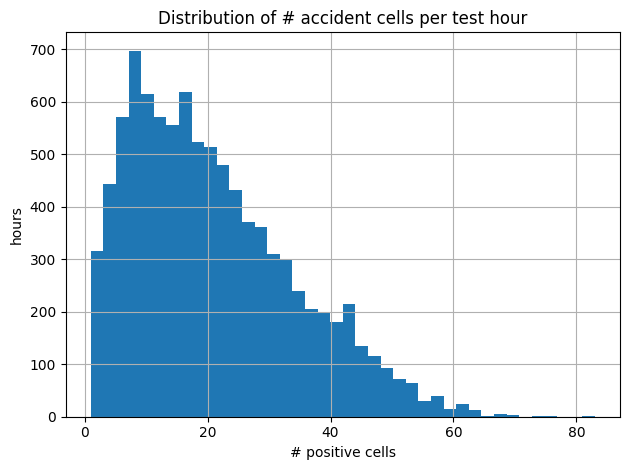

In [3]:
train_pos = train_df.groupby(["hour_bucket", "cell_id"]).size().reset_index(name="cnt")
test_pos  = test_df.groupby(["hour_bucket", "cell_id"]).size().reset_index(name="cnt")

pos_cells_by_hour_train = train_pos.groupby("hour_bucket")["cell_id"].apply(lambda x: set(x.values)).to_dict()
pos_cells_by_hour_test  = test_pos.groupby("hour_bucket")["cell_id"].apply(lambda x: set(x.values)).to_dict()

train_hours = np.array(list(pos_cells_by_hour_train.keys()))
test_hours  = np.array(list(pos_cells_by_hour_test.keys()))

print("Train hours w/ accidents:", len(train_hours))
print("Test hours w/ accidents:",  len(test_hours))

# Sanity check: positives per test hour
pos_counts = pd.Series({hb: sum((c in all_cells_set) for c in cells)
                        for hb, cells in pos_cells_by_hour_test.items()})
pos_counts = pos_counts[pos_counts > 0]

print("Avg positive cells/hour:", float(pos_counts.mean()))
print("Median positive cells/hour:", float(pos_counts.median()))
print("90th percentile:", float(pos_counts.quantile(0.90)))
print("Max:", int(pos_counts.max()))

pos_counts.hist(bins=40)
plt.title("Distribution of # accident cells per test hour")
plt.xlabel("# positive cells")
plt.ylabel("hours")
plt.tight_layout()
plt.show()

4. Baseline-rate features from train only

In [4]:
n_train_hours = train_df["hour_bucket"].nunique()
global_rate = len(train_df) / (n_train_hours * n_cells)

cell_rate = (train_df.groupby("cell_id").size() / n_train_hours)

how_hours = train_df.groupby("hour_of_week")["hour_bucket"].nunique()
counts_cell_how = train_df.groupby(["cell_id", "hour_of_week"]).size()

den = counts_cell_how.index.get_level_values("hour_of_week").map(how_hours).values
cell_how_rate = counts_cell_how / den

rate_dict = cell_rate.to_dict()

def neighbor_rate(clat, clng):
    nbrs = []
    for d1 in (-1, 0, 1):
        for d2 in (-1, 0, 1):
            if d1 == 0 and d2 == 0:
                continue
            nbrs.append(rate_dict.get(f"{clat+d1}_{clng+d2}", global_rate))
    return float(np.mean(nbrs))

cell_feat = pd.DataFrame(index=all_cells.index)
cell_feat["cell_rate"] = cell_rate.reindex(cell_feat.index).fillna(global_rate)
cell_feat["neighbor_rate"] = [neighbor_rate(r.cell_lat, r.cell_lng) for r in all_cells.itertuples()]

print("Global rate:", global_rate)
print("Non-zero cells:", int((cell_feat["cell_rate"] > 0).sum()), "/", n_cells)

Global rate: 0.009514925175367846
Non-zero cells: 2574 / 2574


5. TRUE-hour recency on dense hourly timeline
(Builds recency_by_hour[hb] = (rec_1h_vec, rec_6h_vec, rec_24h_vec) for needed hours.)

In [5]:
rng = np.random.default_rng(42)

TRAIN_HOUR_SAMPLE = min(30000, len(train_hours))
EVAL_HOURS        = min(2000, len(test_hours))

sampled_train_hours = rng.choice(train_hours, size=TRAIN_HOUR_SAMPLE, replace=False)
sampled_test_hours  = rng.choice(test_hours,  size=EVAL_HOURS,        replace=False)

needed_hours = set(pd.to_datetime(np.concatenate([sampled_train_hours, sampled_test_hours])))
min_h, max_h = min(needed_hours), max(needed_hours)

# Build dense hour index (every hour between min/max)
all_hours_full = pd.date_range(min_h, max_h, freq="h")

# Map hour_bucket -> list of cell indices that had >=1 accident in that hour (train-universe cells only)
# Use drop_duplicates so this is "presence per cell-hour" not a count.
tmp = (df[df["cell_id"].isin(all_cells_set)]
       .drop_duplicates(subset=["hour_bucket", "cell_id"])[["hour_bucket", "cell_id"]])

hour_to_cellidx = {}
for hb, grp in tmp.groupby("hour_bucket"):
    hb = pd.Timestamp(hb)
    idxs = [cell_to_idx[c] for c in grp["cell_id"].values]  # all are in all_cells_set already
    if idxs:
        hour_to_cellidx[hb] = idxs

# Rolling state
buf24 = [np.zeros(n_cells, dtype=np.uint8) for _ in range(24)]  # ring buffer for last 24 hours
sum6  = np.zeros(n_cells, dtype=np.int16)  # rolling sum over last 6 hours (past-only for features)
sum24 = np.zeros(n_cells, dtype=np.int16)  # rolling sum over last 24 hours (past-only for features)
prev_hour_vec = np.zeros(n_cells, dtype=np.uint8)  # for rec_1h

recency_by_hour = {}  # hb -> (rec1, rec6, rec24)

for t_i, hb in enumerate(all_hours_full):
    # current hour accident indicator (1 if this cell had >=1 accident at hb)
    cur = np.zeros(n_cells, dtype=np.uint8)
    idxs = hour_to_cellidx.get(hb)
    if idxs:
        cur[np.array(idxs, dtype=int)] = 1

    # recency for hb uses ONLY past hours (< hb)
    rec_1h  = prev_hour_vec.copy()
    rec_6h  = sum6.copy()
    rec_24h = sum24.copy()

    if hb in needed_hours:
        recency_by_hour[hb] = (rec_1h, rec_6h, rec_24h)

    # --- advance rolling windows (CRITICAL ordering) ---
    # grab the vectors leaving the windows BEFORE overwriting the ring slot
    out24 = buf24[t_i % 24]  # hour leaving 24h window
    out6  = buf24[(t_i - 6) % 24] if t_i >= 6 else np.zeros(n_cells, dtype=np.uint8)  # hour leaving 6h window

    # write current hour into ring slot
    buf24[t_i % 24] = cur

    # update rolling sums
    sum24 = sum24 + cur.astype(np.int16) - out24.astype(np.int16)
    sum6  = sum6  + cur.astype(np.int16) - out6.astype(np.int16)

    # advance "previous hour"
    prev_hour_vec = cur

print(f"Recency stored for hours: {len(recency_by_hour)} / needed: {len(needed_hours)}")

# sanity: recency should NOT be all zeros
some_hb = next(iter(recency_by_hour.keys()))
r1, r6, r24 = recency_by_hour[some_hb]
print("Sanity nonzero rates:", float((r1 > 0).mean()), float((r6 > 0).mean()), float((r24 > 0).mean()))

Recency stored for hours: 32000 / needed: 32000
Sanity nonzero rates: 0.0 0.0 0.0


6. Build training set (NEG_RATIO negatives per positive per hour)

In [6]:
NEG_RATIO = 20

def time_feats(ts: pd.Timestamp):
    hour = ts.hour
    dow = ts.dayofweek
    month = ts.month
    return dict(
        hour_sin=np.sin(2*np.pi*hour/24),
        hour_cos=np.cos(2*np.pi*hour/24),
        dow_sin=np.sin(2*np.pi*dow/7),
        dow_cos=np.cos(2*np.pi*dow/7),
        month_sin=np.sin(2*np.pi*month/12),
        month_cos=np.cos(2*np.pi*month/12),
        weekend=int(dow >= 5),
        rush=int((7 <= hour <= 9) or (16 <= hour <= 19)),
        how=dow * 24 + hour
    )

FEATURES = [
    "cell_rate", "neighbor_rate", "cell_how_rate",
    "rec_1h", "rec_6h", "rec_24h",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos", "month_sin", "month_cos",
    "weekend", "rush"
]

X_list, y_list = [], []

for hb in sampled_train_hours:
    hb = pd.Timestamp(hb)
    pos = list(pos_cells_by_hour_train.get(hb, []))
    pos = [c for c in pos if c in all_cells_set]
    if not pos:
        continue

    tf = time_feats(hb)
    pos_set = set(pos)

    need = min(len(pos) * NEG_RATIO, n_cells - len(pos_set))
    mask = ~np.isin(cell_ids, np.array(list(pos_set), dtype=object))
    neg_pool = cell_ids[mask]
    need = min(need, len(neg_pool))
    neg = list(rng.choice(neg_pool, size=need, replace=False))

    cells = pos + neg
    base = cell_feat.reindex(cells)

    how_series = cell_how_rate.xs(tf["how"], level="hour_of_week") if tf["how"] in how_hours.index else pd.Series(dtype=float)
    how_feat = how_series.reindex(cells).fillna(base["cell_rate"]).to_numpy()

    # recency vectors for ALL cells at hb, then slice down to just our sampled cells
    rec_1h_all, rec_6h_all, rec_24h_all = recency_by_hour[hb]
    cell_idx = np.array([cell_to_idx[c] for c in cells], dtype=int)
    rec = np.column_stack([rec_1h_all[cell_idx], rec_6h_all[cell_idx], rec_24h_all[cell_idx]]).astype(float)

    X = np.column_stack([
        base["cell_rate"].to_numpy(),
        base["neighbor_rate"].to_numpy(),
        how_feat,
        rec[:, 0], rec[:, 1], rec[:, 2],
        np.full(len(cells), tf["hour_sin"]),
        np.full(len(cells), tf["hour_cos"]),
        np.full(len(cells), tf["dow_sin"]),
        np.full(len(cells), tf["dow_cos"]),
        np.full(len(cells), tf["month_sin"]),
        np.full(len(cells), tf["month_cos"]),
        np.full(len(cells), tf["weekend"]),
        np.full(len(cells), tf["rush"]),
    ])

    X_list.append(X)
    y_list.extend([1] * len(pos) + [0] * len(neg))

X_train = np.vstack(X_list)
y_train = np.array(y_list)

print("Train rows:", len(y_train))
print("Pos rate:", float(y_train.mean()))
print("Recency nonzero rates:",
      float((X_train[:, 3] > 0).mean()),
      float((X_train[:, 4] > 0).mean()),
      float((X_train[:, 5] > 0).mean()))

Train rows: 11292918
Pos rate: 0.047619047619047616
Recency nonzero rates: 0.01609654829690608 0.05268514302503569 0.11260641403754106


7. Train LightGBM (tuned)

In [7]:
import lightgbm as lgb

pos = float(y_train.sum())
neg = float(len(y_train) - pos)
scale_pos_weight = neg / pos

model = lgb.LGBMClassifier(
    # capacity + regularization
    n_estimators=1200,
    learning_rate=0.03,
    num_leaves=31,               # often generalizes better than 63
    min_child_samples=100,       # reduces overfitting
    reg_lambda=1.0,              # L2 regularization

    # sampling
    subsample=0.8,
    colsample_bytree=0.8,

    # imbalance + misc
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
    verbose=-1
)

model.fit(X_train, y_train)
print("Trained. scale_pos_weight:", float(scale_pos_weight))

Trained. scale_pos_weight: 20.0


8. Evaluate on FULL cell universe per test hour (Recall@Top-K) + Precision@K and HitRate@K

In [8]:
K_VALUES = [10, 50, 100]
TOP_PCT  = 0.01
K_PCT    = max(1, int(n_cells * TOP_PCT))

def build_full_X(hb: pd.Timestamp):
    tf = time_feats(hb)
    base = cell_feat.reindex(cell_ids)

    how_series = cell_how_rate.xs(tf["how"], level="hour_of_week") if tf["how"] in how_hours.index else pd.Series(dtype=float)
    how_feat = how_series.reindex(cell_ids).fillna(base["cell_rate"]).to_numpy()

    rec_1h_all, rec_6h_all, rec_24h_all = recency_by_hour[hb]
    rec = np.column_stack([rec_1h_all, rec_6h_all, rec_24h_all]).astype(float)

    X = np.column_stack([
        base["cell_rate"].to_numpy(),
        base["neighbor_rate"].to_numpy(),
        how_feat,
        rec[:, 0], rec[:, 1], rec[:, 2],
        np.full(n_cells, tf["hour_sin"]),
        np.full(n_cells, tf["hour_cos"]),
        np.full(n_cells, tf["dow_sin"]),
        np.full(n_cells, tf["dow_cos"]),
        np.full(n_cells, tf["month_sin"]),
        np.full(n_cells, tf["month_cos"]),
        np.full(n_cells, tf["weekend"]),
        np.full(n_cells, tf["rush"]),
    ])
    return X

recalls    = {k: [] for k in K_VALUES + ["top_1pct"]}
precisions = {k: [] for k in K_VALUES}
hitrate    = {k: [] for k in K_VALUES}

for hb in sampled_test_hours:
    hb = pd.Timestamp(hb)
    pos_cells = set([c for c in pos_cells_by_hour_test.get(hb, set()) if c in all_cells_set])
    if not pos_cells:
        continue
    n_pos = len(pos_cells)

    X_full = build_full_X(hb)
    proba  = model.predict_proba(X_full)[:, 1]
    ranked_cells = cell_ids[np.argsort(-proba)]

    for k in K_VALUES:
        topk = set(ranked_cells[:k])
        tp   = len(topk & pos_cells)
        recalls[k].append(tp / n_pos)
        precisions[k].append(tp / k)
        hitrate[k].append(1 if tp > 0 else 0)

    topp = set(ranked_cells[:K_PCT])
    recalls["top_1pct"].append(len(topp & pos_cells) / n_pos)

print("=== LightGBM Track 2 (True-hour recency) ===")
for k in K_VALUES:
    print(f"Recall@Top-{k}: {np.mean(recalls[k]):.3f} | Precision@Top-{k}: {np.mean(precisions[k]):.3f} | HitRate@Top-{k}: {np.mean(hitrate[k]):.3f}")
print(f"Recall@Top-1% (K={K_PCT}): {np.mean(recalls['top_1pct']):.3f}")

=== LightGBM Track 2 (True-hour recency) ===
Recall@Top-10: 0.134 | Precision@Top-10: 0.269 | HitRate@Top-10: 0.873
Recall@Top-50: 0.382 | Precision@Top-50: 0.163 | HitRate@Top-50: 0.974
Recall@Top-100: 0.531 | Precision@Top-100: 0.115 | HitRate@Top-100: 0.989
Recall@Top-1% (K=25): 0.253


9. FAIR baseline evaluation (same valid hours) + comparison plot + exports

    Baseline = mean(cell_rate, cell_how_rate, neighbor_rate) from TRAIN only

    Also recompute model Recall@K on the exact same valid hours (apples-to-apples)

Valid test hours used for evaluation: 2000 / sampled: 2000
Baseline: {'Top-10': 0.1278353612171985, 'Top-50': 0.37073390340238155, 'Top-100': 0.513819713382582, 'Top-1%': 0.24676478687277834}
Model: {'Top-10': 0.13403825823824353, 'Top-50': 0.3822686432085683, 'Top-100': 0.5312877628020002, 'Top-1%': 0.2525913168604952}
Delta: {'Top-10': 0.00620289702104504, 'Top-50': 0.011534739806186745, 'Top-100': 0.017468049419418152, 'Top-1%': 0.00582652998771685}


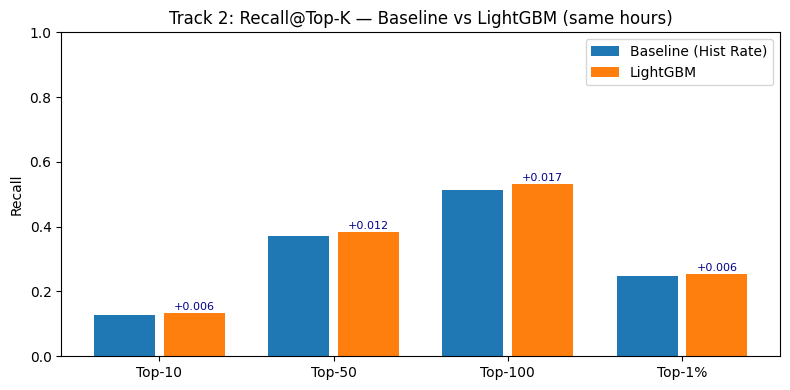

cell_rate        7150
cell_how_rate    7140
neighbor_rate    4954
hour_cos         3038
hour_sin         2663
dow_sin          2238
month_cos        2093
month_sin        2023
rec_24h          1650
dow_cos           978
rec_6h            818
rec_1h            706
dtype: int32

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- 9.1 Build a single shared list of valid test hours (>=1 accident cell in train-universe)
valid_test_hours = []
for hb in sampled_test_hours:
    hb = pd.Timestamp(hb)
    pos_cells = set([c for c in pos_cells_by_hour_test.get(hb, set()) if c in all_cells_set])
    if pos_cells:
        valid_test_hours.append(hb)

print(f"Valid test hours used for evaluation: {len(valid_test_hours)} / sampled: {len(sampled_test_hours)}")

# ---- 9.2 Baseline scoring function (TRAIN-only rates)
def baseline_scores_for_hour(hb: pd.Timestamp) -> np.ndarray:
    tf = time_feats(hb)

    # cell_rate + neighbor_rate from TRAIN-only features
    scores = pd.DataFrame(index=cell_ids)
    scores["cell_rate"] = cell_feat["cell_rate"].reindex(cell_ids).fillna(global_rate).to_numpy()
    scores["neighbor_rate"] = cell_feat["neighbor_rate"].reindex(cell_ids).fillna(global_rate).to_numpy()

    # cell_how_rate from TRAIN-only (with fallback)
    if tf["how"] in how_hours.index:
        how_series = cell_how_rate.xs(tf["how"], level="hour_of_week")
        scores["cell_how_rate"] = how_series.reindex(cell_ids).fillna(scores["cell_rate"]).to_numpy()
    else:
        scores["cell_how_rate"] = scores["cell_rate"]

    return scores.mean(axis=1).to_numpy()

# ---- 9.3 Evaluate baseline and model on the same valid hours
baseline_recalls = {k: [] for k in K_VALUES + ["top_1pct"]}
model_recalls    = {k: [] for k in K_VALUES + ["top_1pct"]}

for hb in valid_test_hours:
    pos_cells = set([c for c in pos_cells_by_hour_test.get(hb, set()) if c in all_cells_set])
    n_pos = len(pos_cells)

    # Baseline ranking
    s_base = baseline_scores_for_hour(hb)
    ranked_base = cell_ids[np.argsort(-s_base)]

    for k in K_VALUES:
        topk = set(ranked_base[:k])
        baseline_recalls[k].append(len(topk & pos_cells) / n_pos)

    topp = set(ranked_base[:K_PCT])
    baseline_recalls["top_1pct"].append(len(topp & pos_cells) / n_pos)

    # Model ranking (recomputed here for strict fairness)
    X_full = build_full_X(hb)
    proba  = model.predict_proba(X_full)[:, 1]
    ranked_model = cell_ids[np.argsort(-proba)]

    for k in K_VALUES:
        topk = set(ranked_model[:k])
        model_recalls[k].append(len(topk & pos_cells) / n_pos)

    topp = set(ranked_model[:K_PCT])
    model_recalls["top_1pct"].append(len(topp & pos_cells) / n_pos)

baseline_vals = {
    "Top-10":  float(np.mean(baseline_recalls[10])),
    "Top-50":  float(np.mean(baseline_recalls[50])),
    "Top-100": float(np.mean(baseline_recalls[100])),
    "Top-1%":  float(np.mean(baseline_recalls["top_1pct"])),
}
model_vals = {
    "Top-10":  float(np.mean(model_recalls[10])),
    "Top-50":  float(np.mean(model_recalls[50])),
    "Top-100": float(np.mean(model_recalls[100])),
    "Top-1%":  float(np.mean(model_recalls["top_1pct"])),
}
delta = {k: model_vals[k] - baseline_vals[k] for k in baseline_vals}

print("Baseline:", baseline_vals)
print("Model:", model_vals)
print("Delta:", delta)

# ---- 9.4 Plot + annotate deltas
labels = list(baseline_vals.keys())
b = [baseline_vals[k] for k in labels]
m = [model_vals[k] for k in labels]

x = np.arange(len(labels))
plt.figure(figsize=(8, 4))
plt.bar(x - 0.2, b, 0.35, label="Baseline (Hist Rate)")
plt.bar(x + 0.2, m, 0.35, label="LightGBM")
plt.xticks(x, labels)
plt.ylim(0, 1)
plt.ylabel("Recall")
plt.title("Track 2: Recall@Top-K — Baseline vs LightGBM (same hours)")
plt.legend()

ax = plt.gca()
for i, (bv, mv) in enumerate(zip(b, m)):
    ax.text(i + 0.2, mv + 0.01, f"+{mv-bv:.3f}", ha="center", fontsize=8, color="darkblue")

plt.tight_layout()
plt.savefig("outputs/track2_lgbm_vs_baseline.png", dpi=200)
plt.show()

# ---- 9.5 Save CSV metrics + feature importances
pd.DataFrame({
    "metric": labels,
    "baseline": b,
    "model": m,
    "delta": [delta[k] for k in labels]
}).to_csv("outputs/track2_lgbm_metrics.csv", index=False)

imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=False)
imp.to_csv("outputs/track2_lgbm_feature_importance.csv")
imp.head(12)

In [10]:
# =========================
# Significance test — is LightGBM improvement over baseline significant?
# Paired across the SAME valid_test_hours (hours with >=1 accident cell).
# Reports bootstrap 95% CI for mean delta and a p-value (if SciPy available).
# =========================
import numpy as np

# Choose which K to test significance for (most meaningful: 100 or Top-1%)
K_TO_TEST = 100   # try 10, 50, 100; or set to "top_1pct" below
B = 5000          # bootstrap resamples

# ---- Helper: compute per-hour recall for baseline and model ----
per_hour_base = []
per_hour_model = []

for hb in valid_test_hours:
    hb = pd.Timestamp(hb)
    pos_cells = set([c for c in pos_cells_by_hour_test.get(hb, set()) if c in all_cells_set])
    if not pos_cells:
        continue
    n_pos = len(pos_cells)

    # baseline ranking
    s = baseline_scores_for_hour(hb)
    ranked_base = cell_ids[np.argsort(-s)]

    # model ranking
    X_full = build_full_X(hb)
    proba = model.predict_proba(X_full)[:, 1]
    ranked_model = cell_ids[np.argsort(-proba)]

    if K_TO_TEST == "top_1pct":
        K_use = K_PCT
    else:
        K_use = int(K_TO_TEST)

    top_base = set(ranked_base[:K_use])
    top_model = set(ranked_model[:K_use])

    per_hour_base.append(len(top_base & pos_cells) / n_pos)
    per_hour_model.append(len(top_model & pos_cells) / n_pos)

per_hour_base = np.array(per_hour_base, dtype=float)
per_hour_model = np.array(per_hour_model, dtype=float)
d = per_hour_model - per_hour_base

print(f"Hours evaluated: {len(d)}")
print(f"Mean baseline recall: {per_hour_base.mean():.4f}")
print(f"Mean model recall   : {per_hour_model.mean():.4f}")
print(f"Mean delta          : {d.mean():.4f}")

# ---- Paired bootstrap CI for mean delta (recommended) ----
rng = np.random.default_rng(0)
n = len(d)
boot_means = np.empty(B, dtype=float)
for b in range(B):
    idx = rng.integers(0, n, size=n)     # resample hours with replacement
    boot_means[b] = d[idx].mean()

lo, hi = np.quantile(boot_means, [0.025, 0.975])
print(f"Bootstrap 95% CI for mean delta: [{lo:.4f}, {hi:.4f}]")
print("Significant at 5% (CI entirely > 0)?", "YES" if lo > 0 else "NO")

# ---- Optional: paired t-test / Wilcoxon if SciPy exists ----
try:
    from scipy.stats import ttest_1samp, wilcoxon
    t_p = ttest_1samp(d, 0.0).pvalue
    w_p = wilcoxon(d).pvalue
    print(f"Paired t-test p-value      : {t_p:.4g}")
    print(f"Wilcoxon signed-rank p-val : {w_p:.4g}")
except Exception as e:
    pass

Hours evaluated: 2000
Mean baseline recall: 0.5138
Mean model recall   : 0.5313
Mean delta          : 0.0175
Bootstrap 95% CI for mean delta: [0.0139, 0.0210]
Significant at 5% (CI entirely > 0)? YES
Paired t-test p-value      : 9.493e-22
Wilcoxon signed-rank p-val : 1.434e-23


In [12]:
# =========================
# Dashboard CSV Exports (Hour-of-Week Risk Tables)
# Produces:
#   outputs/dashboard_cell_risk.csv
#   outputs/dashboard_hourly_summary.csv
#   outputs/dashboard_topk_snapshot.csv
# =========================
import numpy as np
import pandas as pd
import os

os.makedirs("outputs", exist_ok=True)

DAY_NAMES = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# --- Use cell centers (recommended for dashboards) ---
# Your all_cells has integer bin ids (cell_lat, cell_lng). Convert to approx center coords.
cells_info = all_cells.copy()
cells_info["cell_center_lat"] = (cells_info["cell_lat"] + 0.5) * GRID_DEG
cells_info["cell_center_lng"] = (cells_info["cell_lng"] + 0.5) * GRID_DEG

# Pre-align static features once
cell_rate_vec = cell_feat["cell_rate"].reindex(cell_ids).to_numpy()
neighbor_vec  = cell_feat["neighbor_rate"].reindex(cell_ids).to_numpy()

rows = []
topk_rows = []
hourly_rows = []

K_LIST = [10, 50, 100]

for how in range(168):
    day = how // 24
    hour = how % 24
    day_name = DAY_NAMES[day]

    # cell_how_rate for this how (fallback to cell_rate)
    if how in how_hours.index:
        how_series = cell_how_rate.xs(how, level="hour_of_week")  # index: cell_id
        how_vec = how_series.reindex(cell_ids).to_numpy(copy=True)  # ensure writable
        nan_mask = np.isnan(how_vec)
        if nan_mask.any():
            how_vec[nan_mask] = cell_rate_vec[nan_mask]
    else:
        how_vec = cell_rate_vec.copy()

    # Risk score for dashboard:
    # Use SAME baseline definition you used in Cell 9 baseline: mean(cell_rate, cell_how_rate, neighbor_rate)
    risk_score = (cell_rate_vec + how_vec + neighbor_vec) / 3.0

    # Rank within this hour_of_week (1 = highest)
    order = np.argsort(-risk_score)
    pred_rank = np.empty_like(order)
    pred_rank[order] = np.arange(1, len(cell_ids) + 1)

    # Flags
    is_top_10  = (pred_rank <= 10).astype(int)
    is_top_50  = (pred_rank <= 50).astype(int)
    is_top_100 = (pred_rank <= 100).astype(int)

    # Main per-cell table
    df_how = pd.DataFrame({
        "cell_id": cell_ids,
        "cell_lat": cells_info.loc[cell_ids, "cell_center_lat"].to_numpy(),
        "cell_lng": cells_info.loc[cell_ids, "cell_center_lng"].to_numpy(),
        "hour_of_week": how,
        "day_name": day_name,
        "hour": hour,
        "risk_score": risk_score,
        "cell_rate": cell_rate_vec,
        "cell_how_rate": how_vec,
        "neighbor_rate": neighbor_vec,
        "pred_rank": pred_rank,
        "is_top_10": is_top_10,
        "is_top_50": is_top_50,
        "is_top_100": is_top_100,
    })
    rows.append(df_how)

    # Hourly summary
    hourly_rows.append({
        "hour_of_week": how,
        "day_name": day_name,
        "hour": hour,
        "avg_risk_score": float(np.mean(risk_score)),
        # optional: observed count in TRAIN for this slot
        "historical_accident_count": int(train_df[train_df["hour_of_week"] == how].shape[0]),
    })

    # Top-K snapshot (optional table)
    for k, label in [(10, "top10"), (50, "top50"), (100, "top100")]:
        top_idx = order[:k]
        snap = df_how.iloc[top_idx][
            ["hour_of_week", "day_name", "hour", "cell_id", "cell_lat", "cell_lng", "risk_score", "pred_rank"]
        ].copy()
        snap.insert(3, "k_label", label)
        topk_rows.append(snap)

dashboard_cell_risk = pd.concat(rows, ignore_index=True)
dashboard_hourly_summary = pd.DataFrame(hourly_rows)
dashboard_topk_snapshot = pd.concat(topk_rows, ignore_index=True)

# Save files
dashboard_cell_risk.to_csv("outputs/dashboard_cell_risk.csv", index=False)
dashboard_hourly_summary.to_csv("outputs/dashboard_hourly_summary.csv", index=False)
dashboard_topk_snapshot.to_csv("outputs/dashboard_topk_snapshot.csv", index=False)

print("Saved:")
print(" - outputs/dashboard_cell_risk.csv", dashboard_cell_risk.shape)
print(" - outputs/dashboard_hourly_summary.csv", dashboard_hourly_summary.shape)
print(" - outputs/dashboard_topk_snapshot.csv", dashboard_topk_snapshot.shape)

Saved:
 - outputs/dashboard_cell_risk.csv (432432, 14)
 - outputs/dashboard_hourly_summary.csv (168, 5)
 - outputs/dashboard_topk_snapshot.csv (26880, 9)
